In [1]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=3.5)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 1, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
mu, sigma_m, sigma_q, T = npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[2]]), 10

intensity_matrix_markov = dd._buildK(n_states, mu, sigma_m)
intensity_matrix_quantum = qd._buildH(n_states, mu, sigma_q)


In [4]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64),
 Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64))

In [5]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Lower")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Lower")
phi_0_markov, phi_0_quantum

(Array([[[[1.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.]]]], dtype=float64),
 Array([[[[1.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.]]]], dtype=float64))

In [6]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Uniform")
phi_0_markov, phi_0_quantum

(Array([[[[0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714],
          [0.14285714]]]], dtype=float64),
 Array([[[[0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447],
          [0.37796447]]]], dtype=float64))

In [7]:
scx.linalg.expm(intensity_matrix_markov * 2).shape

(1, 1, 7, 7)

In [8]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    for t in np.arange(0, T, steps):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(0, T, steps):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
        

In [9]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0.5,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [10]:
intensity_matrix_quantum

Array([[[[0.+3.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-2.j, 0.+2.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-2.j, 0.+1.j, 0.-2.j, 0.-0.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-2.j, 0.-0.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-1.j, 0.-2.j, 0.-0.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-2.j, 0.-2.j],
         [0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-0.j, 0.-2.j, 0.-3.j]]]],      dtype=complex128)

In [11]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov).squeeze())

,0,1,2,3,4,5,6
0,0.213582,0.089562,0.020739,0.003309,0.000403,0.000042,0.000013
1,0.358260,0.275799,0.099490,0.021947,0.003434,0.000442,0.000166
2,0.249035,0.298482,0.258683,0.096554,0.021664,0.003766,0.001717
3,0.120865,0.197687,0.289676,0.257834,0.097551,0.025486,0.014567
4,0.058209,0.094446,0.195141,0.292667,0.269302,0.129952,0.096796
5,0.111987,0.050572,0.103420,0.229544,0.389871,0.483230,0.476110
6,0.125943,0.034727,0.038445,0.098758,0.217832,0.357085,0.410633


In [12]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states - n_states//2 ).assign(time=lambda df: df.time*steps)
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").reset_index(names="states").assign(states = lambda df: df.states - n_states//2).assign(time=lambda df: df.time*steps)
df_markov_plot.query("states==3 | states==2")

,states,prior,time,value
5,2,Upper,0.0,0.000000
6,3,Upper,0.0,1.000000
12,2,Uniform,0.0,0.142857
13,3,Uniform,0.0,0.142857
19,2,Lower,0.0,0.000000
...,...,...,...,...
2085,3,Upper,9.9,0.335647
2091,2,Uniform,9.9,0.478469
2092,3,Uniform,9.9,0.358441
2098,2,Lower,9.9,0.603119


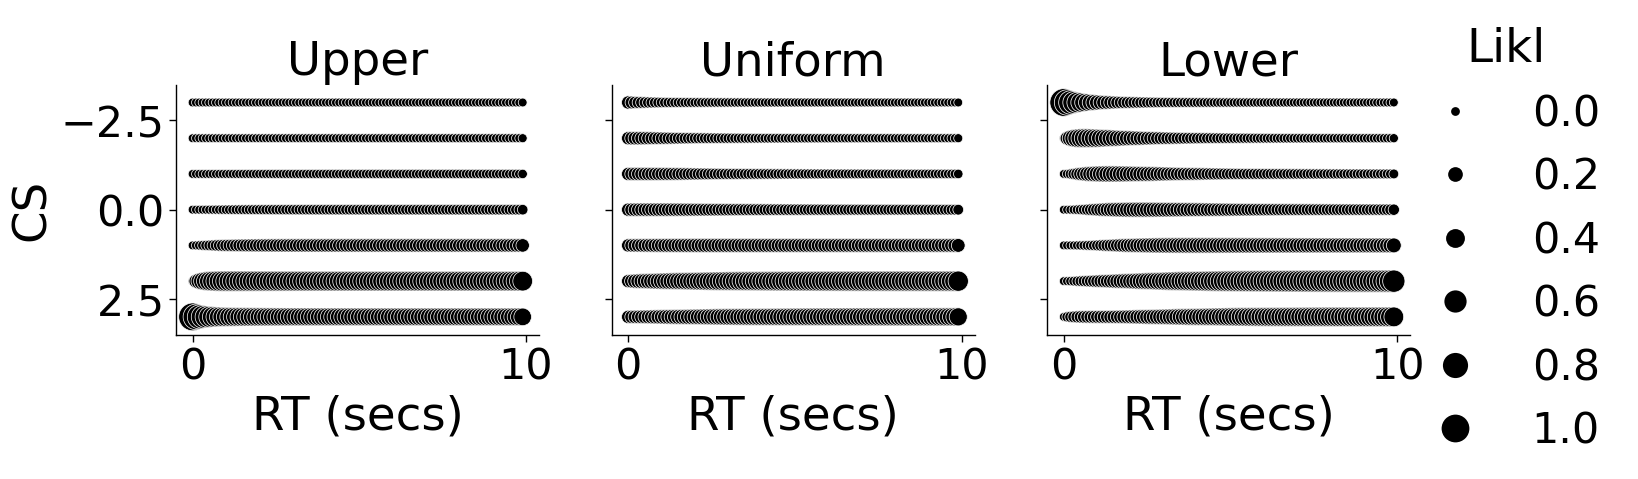

In [32]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, facet_kws={"ylim":(-3.5,3.5)})#, facet_kws={"xlim":(0,32)})
f.set_titles("{col_name}")
f.legend.set_title("Likl")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")
plt.gca().invert_yaxis()
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")

In [14]:
df_quantum_plot.query("time == 0")

,states,prior,time,value
0,-3,Upper,0.0,0.000000
1,-2,Upper,0.0,0.000000
2,-1,Upper,0.0,0.000000
3,0,Upper,0.0,0.000000
4,1,Upper,0.0,0.000000
5,2,Upper,0.0,0.000000
6,3,Upper,0.0,1.000000
7,-3,Uniform,0.0,0.142857
8,-2,Uniform,0.0,0.142857
9,-1,Uniform,0.0,0.142857


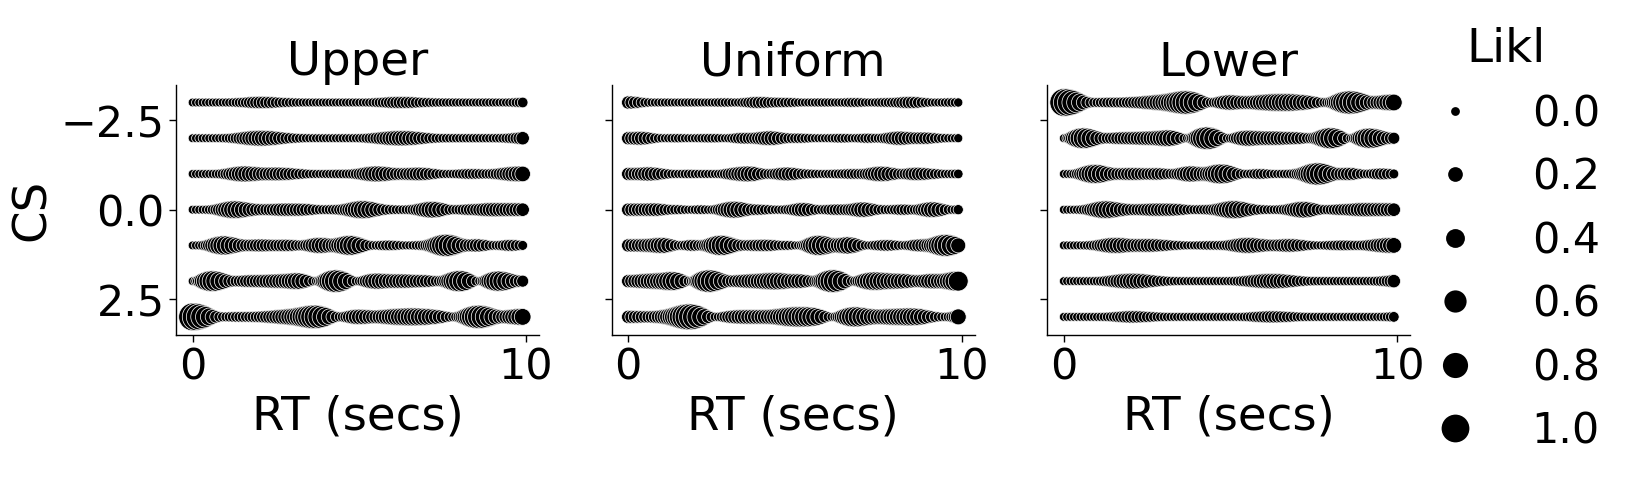

In [15]:
f = sns.relplot(df_quantum_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", facet_kws={"ylim":(-3.5,3.5)})
f.set_titles("{col_name}")
f.legend.set_title("Likl")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")
plt.gca().invert_yaxis()

In [16]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [17]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu, sigma_m in zip([npx.asarray([[0.01]]), npx.asarray([[1]]), npx.asarray([[3]])], [npx.asarray([[1]]), npx.asarray([[2]]), npx.asarray([[2]])]):
    intensity_matrix_markov = dd._buildK(n_states, mu, sigma_m)
    print(intensity_matrix_markov)
    intensity_matrix_quantum = qd._buildH(n_states, mu, sigma_m)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []
        for t in np.arange(0,T,steps):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(0,T,steps):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        

[[[[-1.     0.495  0.     0.     0.     0.     0.   ]
   [ 1.    -1.     0.495  0.     0.     0.     0.   ]
   [ 0.     0.505 -1.     0.495  0.     0.     0.   ]
   [ 0.     0.     0.505 -1.     0.495  0.     0.   ]
   [ 0.     0.     0.     0.505 -1.     0.495  0.   ]
   [ 0.     0.     0.     0.     0.505 -1.     1.   ]
   [ 0.495  0.     0.     0.     0.     0.505 -1.   ]]]]
[[[[-2.   0.5  0.   0.   0.   0.   0. ]
   [ 2.  -2.   0.5  0.   0.   0.   0. ]
   [ 0.   1.5 -2.   0.5  0.   0.   0. ]
   [ 0.   0.   1.5 -2.   0.5  0.   0. ]
   [ 0.   0.   0.   1.5 -2.   0.5  0. ]
   [ 0.   0.   0.   0.   1.5 -2.   2. ]
   [ 0.5  0.   0.   0.   0.   1.5 -2. ]]]]
[[[[-2.  -0.5  0.   0.   0.   0.   0. ]
   [ 2.  -2.  -0.5  0.   0.   0.   0. ]
   [ 0.   2.5 -2.  -0.5  0.   0.   0. ]
   [ 0.   0.   2.5 -2.  -0.5  0.   0. ]
   [ 0.   0.   0.   2.5 -2.  -0.5  0. ]
   [ 0.   0.   0.   0.   2.5 -2.   2. ]
   [-0.5  0.   0.   0.   0.   2.5 -2. ]]]]


In [18]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*steps)
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*steps)
df_markov1_plot.query("value > 3")

,prior,mu,time,value


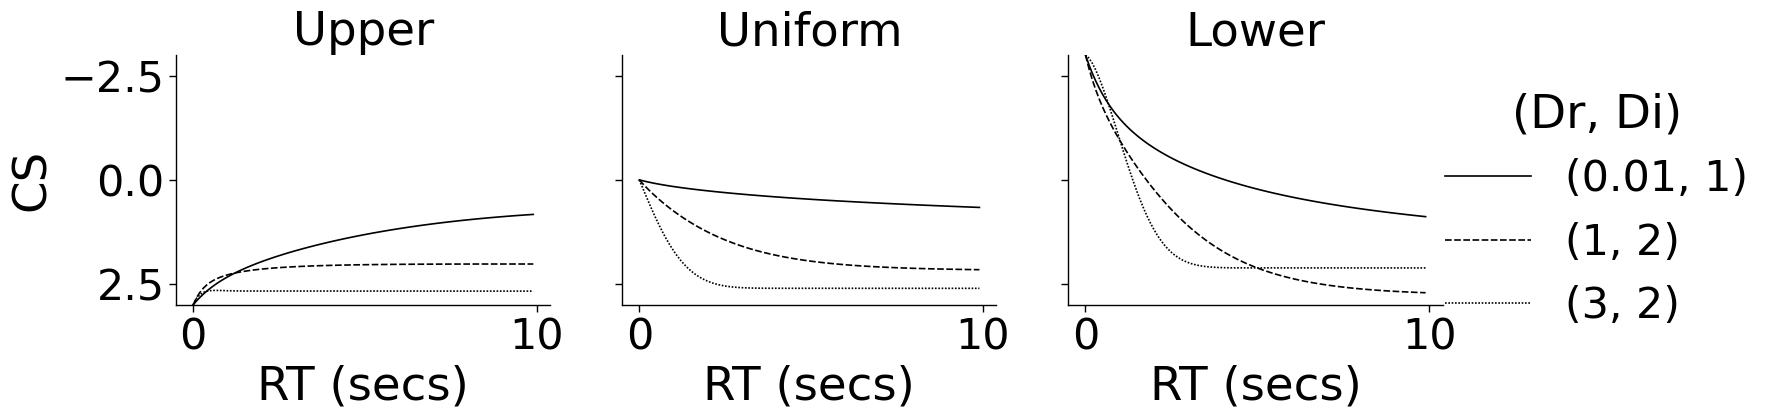

In [19]:
f = sns.relplot(df_markov1_plot,
x="time", y="value", col="prior", style="mu", kind="line", color="Black", facet_kws={"ylim":(-(n_states//2), (n_states//2))})
f.legend.set_title("(Dr, Di)")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")
f.set_titles("{col_name}")
plt.gca().invert_yaxis()

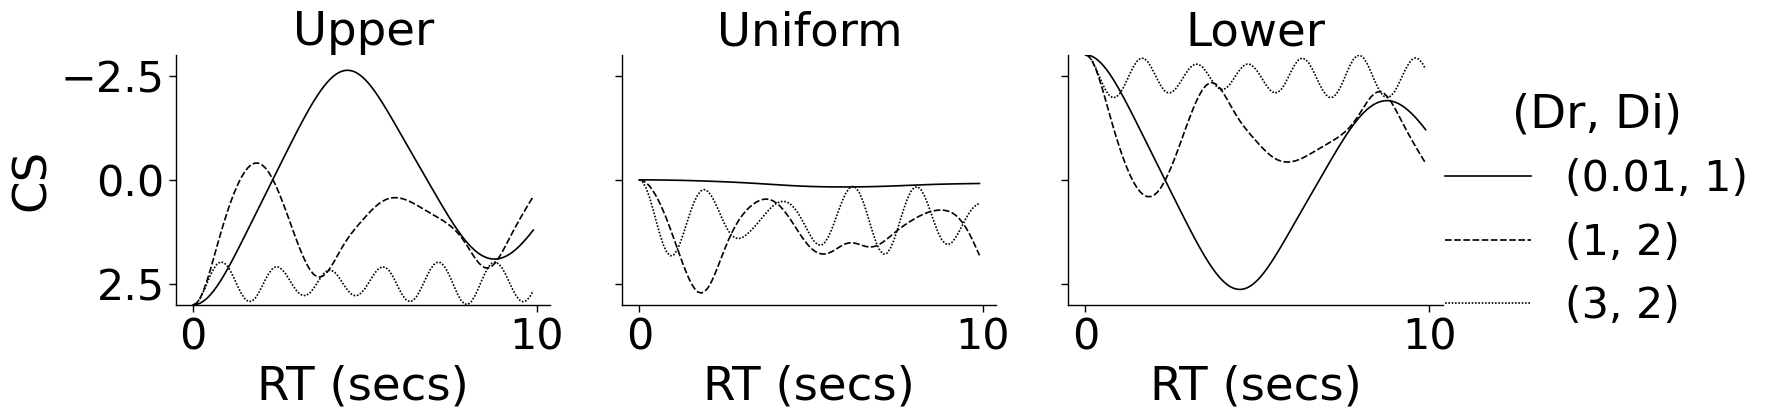

In [20]:
f = sns.relplot(df_quantum1_plot,
x="time", y="value", col="prior", style="mu", kind="line", color="Black", facet_kws={"sharey":True, "ylim":(-(n_states//2), (n_states//2))})#, palette="Greys")
f.legend.set_title("(Dr, Di)")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")
f.set_titles("{col_name}")
plt.gca().invert_yaxis()

# Interference

## No Model Interference

### Markov

In [21]:
t = 5
t1 = 2
t2 = t - t1

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

In [22]:
m_Mn_i = npx.eye(n_states) - m_Mc
m_Mn_i

Array([[1. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.2]], dtype=float64)

In [23]:
P_markov_t1.shape

(1, 1, 7, 1)

In [24]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

(7, 1)

In [25]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

(Array(0.79171667, dtype=float64), Array([[0.01236979]], dtype=float64))

In [26]:
(m_Mc @ P_markov_t2).sum()

Array(0.33155349, dtype=float64)

In [27]:
(m_Mn_i @ P_markov_t1).sum()

Array(0.64236168, dtype=float64)

In [28]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

(Array(0.79171667, dtype=float64), Array(0.97391516, dtype=float64))

In [29]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [30]:
m_Mn_i

Array([[0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.5, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1]], dtype=float64)

In [31]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

(Array(0.79185982, dtype=float64), Array(1.13334476, dtype=float64))